# Hybrid Rotator 90 Degree

Converts TE -> TM. The structure is a digital metamaterial mapped from bit array [0,1,0,1,1,0,1,...] into a 3D structure. In this array, '0' represents as air block and '1' represents as silicon block. This type of metamaterial can easily pass SiEpic DRC and much more manufacturable than the usual inverse design structure.

References: 
- [Base TE<->TM Polarization Rotator using Digital Metamaterial by Majumder](https://opg.optica.org/oe/fulltext.cfm?uri=oe-25-17-19721)
- [Inverse Design with AM-FEM (not FDTD but the adjoint method can be applied with optigrad tidy3d)](https://opg.optica.org/oe/fulltext.cfm?uri=oe-34-2-2047)

## Geometry Creation
create from defining the tech and ports. Then create the core rotator. After the core, create the top level circuit.

In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging.level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam(top_oxide_thickness=-0.3) #idk why butuh offset segini pas dicek di 3d
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
# lower resolution for cheaper simulation. initially it was set at 101 now lower to 41
wavelengths = np.linspace(1.53, 1.57, 41)
freqs = pf.C_0 / wavelengths

14:28:24 SE Asia Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\James\.config\tidy3d'. Found legacy 
                               directory at 'C:\Users\James\.tidy3d', which will
                               be ignored. Tidy3D configuration now uses        
                               'C:\Users\James\.config\tidy3d\config.toml'.     

14:28:29 SE Asia Standard Time WARNING: The material-library variant            
                               'Palik_Lossless' is deprecated and maps to       
                               'Palik_LowLoss' because it contains a tiny fitted
                               loss despite its name. Use 'Palik_NoLoss' where  
                               available for a zero-loss Palik model.           

LiveViewer started at http://localhost:54090


In [2]:
dual_mode_spec = siepic_tech.ports["TE_1550_500"].copy()
dual_mode_spec.num_modes = 2  # Use both modes

siepic_tech.add_port("TE-TM_1550_500", dual_mode_spec)
siepic_tech.ports["TE-TM_1550_500"]

PortSpec(description="Strip TE 1550 nm, w=500 nm", width=1.5, limits=(-0.6, 0.82), num_modes=2, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))])

In [3]:
# digital metamaterial based on 0 and 1, 0 is air, 1 is silicon

# max_pixels = total element in array
rot_length = 5.0
rot_width = 1.5
wg_resolution = 0.1
max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)
print(max_pixels)

# bit array covers the whole range with no numeric ceiling: all-air, all-silicon, or anything between
all_air = np.zeros(max_pixels, dtype=np.uint8)
all_silicon = np.ones(max_pixels, dtype=np.uint8)
random_pattern = np.random.default_rng(0).integers(0, 2, size=max_pixels, dtype=np.uint8)

# print the first 10 elements of each pattern for verification
print(all_air[:10], all_silicon[:10], random_pattern[:10])

750
[0 0 0 0 0 0 0 0 0 0] [1 1 1 1 1 1 1 1 1 1] [0 1 1 1 1 1 0 1 0 1]


In [4]:
# number to bit array conversion
def number_to_bits(n: int, num_bits: int) -> np.ndarray:
    bit_string = format(n, f'0{num_bits}b')  # MSB-first, zero-padded to num_bits
    return np.array(list(bit_string), dtype=np.uint8)

pattern = number_to_bits(123456789012345678901234567890, max_pixels)
print(pattern[:10])


# bit array to number conversion
def bits_to_number(bits: np.ndarray) -> int:
    bit_string = ''.join(bits.astype(str))
    return int(bit_string, 2)

n = bits_to_number(pattern)
print(n)

[0 0 0 0 0 0 0 0 0 0]
123456789012345678901234567890


In [5]:
# digital metamaterial based on 0 and 1, 0 is air, 1 is silicon
# max pixels = rot_length/wg_resolution * rot_width/wg_resolution = 5.0/0.1 * 1.5/0.1 = 750

@pf.parametric_component
def create_hybrid_rotator_90(*, bits, rot_length = 5.0, rot_width = 1.5, wg_resolution = 0.1):

    wg_height = 0.22
    max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)

    # a reminder to connect to the waveguides on the left and right sides of the component
    # i think we can simulate with what we have now
    #wg_length = 2.0
    #wg_width = 0.5

    bits = np.asarray(bits, dtype=np.uint8)
    if bits.shape != (max_pixels,):
        raise ValueError(f"bits must have shape ({max_pixels},), got {bits.shape}")

    # Create an empty component named "HybridRotator"
    hybrid_rotator_90 = pf.Component("HybridRotator90")

    # Create the digital metamaterial based on the bit array
    n = 0
    for i in range(int(rot_width/wg_resolution)):
        for j in range(int(rot_length/wg_resolution)):
            if bits[n]:
                # Create a silicon rectangle for each "1" pixel
                x = j * wg_resolution + wg_resolution/2 - rot_length/2
                y = rot_width/2 - wg_resolution/2 - i*wg_resolution
                silicon = pf.Rectangle(size=(wg_resolution, wg_resolution), center=(x, y))
                hybrid_rotator_90.add("Si", silicon)
            n += 1

    hybrid_rotator_90.add_port(
        pf.Port(center=(-rot_length/2, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )

    hybrid_rotator_90.add_port(
        pf.Port(center=(rot_length/2, 0), input_direction=180, spec=siepic_tech.ports["TE-TM_1550_500"])
    )

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    input_monitor = td.FieldMonitor(
        center=[-rot_length/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="input",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    output_monitor = td.FieldMonitor(
        center=[rot_length/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="output",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    # Include the Tidy3D simulation model
    hybrid_rotator_90.add_model(pf.Tidy3DModel(monitors=[field_monitor, input_monitor, output_monitor]), "Tidy3DModel")
    return hybrid_rotator_90


# Instantiate the component with a bit array: length max_pixels, 0 = air, 1 = silicon.
# Covers the whole range with no numeric ceiling, e.g.:
#   np.zeros(max_pixels, dtype=np.uint8)                                    -> all air
#   np.ones(max_pixels, dtype=np.uint8)                                     -> all silicon
#   np.random.default_rng(seed).integers(0, 2, size=max_pixels, dtype=np.uint8) -> random pattern
rot_length, rot_width, wg_resolution = 5.0, 1.5, 0.1
max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)
bits = np.random.default_rng(0).integers(0, 2, size=max_pixels, dtype=np.uint8)

hybrid_rotator_90 = create_hybrid_rotator_90(bits=bits, rot_length=rot_length, rot_width=rot_width, wg_resolution=wg_resolution)
viewer(hybrid_rotator_90)

In [6]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(hybrid_rotator_90, plot_type="3d")

In [7]:
n = bits_to_number(bits)
print(n)

2903077976970071805342230547150527928031182210404388204938712757223316085135301030866034917955810872705958788835117362110056504052952848499838493929608989008368304918490396227937313994398795125963079987301232525352133440497577


In [8]:
# Connect to short straight waveguide for top level simulation
@pf.parametric_component
def create_hybrid_rotator_90_with_wg(wg_length = 2.0, use_gc = False):

    wg_height = 0.22

    hybrid_rotator_90_with_wg = pf.Component("hybrid_rotator_90_with_wg")

    half_straight1 = pf.parametric.straight(port_spec="TE_1550_500", length=wg_length)
    half_straight2 = pf.parametric.straight(port_spec="TE-TM_1550_500", length=wg_length)
    grating_coupler = siepic.component("ebeam_gc_te1550")
    hybrid_rotator_90 = create_hybrid_rotator_90(bits=bits, rot_length=rot_length, rot_width=rot_width, wg_resolution=wg_resolution)

    # add reference
    rot1_ref = hybrid_rotator_90_with_wg.add_reference(hybrid_rotator_90)
    hst1_ref = hybrid_rotator_90_with_wg.add_reference(half_straight1)
    hst2_ref = hybrid_rotator_90_with_wg.add_reference(half_straight2)

    # connect input waveguide to rotator, then connect output rotator to output waveguide
    # sesudah connect ke sebelum
    rot1_ref.connect("P0", hst1_ref["P1"])
    hst2_ref.connect("P0", rot1_ref["P1"])

    # Connect to gc by adding ref then connect to input of waveguide
    if use_gc:
        gc1_ref = hybrid_rotator_90_with_wg.add_reference(grating_coupler)
        hst1_ref.connect("P0", gc1_ref["P0"])

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    input_monitor = td.FieldMonitor(
        center=[0, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="input",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    output_monitor = td.FieldMonitor(
        center=[rot_length + 2*wg_length, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="output",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    # TOP LEVEL PORTS

    # auto assign port but this made the P1 also TE while we want the output has different port
    # hybrid_rotator_90_with_wg.add_port(hybrid_rotator_90_with_wg.detect_ports(["TE_1550_500"], on_boundary="x"))

    hybrid_rotator_90_with_wg.add_port(
        pf.Port(center=(0, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )

    hybrid_rotator_90_with_wg.add_port(
        pf.Port(center=(rot_length + 2*wg_length, 0), input_direction=180, spec=siepic_tech.ports["TE-TM_1550_500"])
    )
    hybrid_rotator_90_with_wg.add_model(pf.Tidy3DModel(
        monitors=[field_monitor, input_monitor, output_monitor]
        ), "Tidy3DModel")


    return hybrid_rotator_90_with_wg

rot_top = create_hybrid_rotator_90_with_wg(wg_length=2.0, use_gc=False)
viewer(rot_top)

In [9]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(rot_top, plot_type="3d")

In [10]:
#ModeSolver

In [11]:
# janlup estimate cost simulation untuk geometri ini
# untuk 1.53 to 1.57 um dengan 41 points, estimasi flexcredit = 3.012 worst case, 0.592 actual simulation, lama simulasi = 1 menit 38 s

simulations = rot_top.active_model.get_simulations(rot_top, freqs)

# simulations.keys()
td.web.Batch(simulations=simulations).estimate_cost()

14:28:38 SE Asia Standard Time No Flexcredit cost for the whole batch as all    
                               simulations were restored from local cache.

0.0

14:28:40 SE Asia Standard Time Loading simulation from local cache. View cached 
                               task using web UI at                             
                               ]8;id=809734;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=902122;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6\taskId]8;;\
                               ]8;id=809734;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6\=]8;;\]8;id=725130;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6\fdve]8;;\]8;id=809734;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6\-a017be9d-4ab2-4dd5-b6fd-6cec68e2dff6']8;;\.

14:28:42 SE Asia Standard Time Loading simulation from local cache. View cached 
                               task using web UI at                             
                               ]8;id=707001;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e076f0c7-be21-44eb-8383-607383a3394a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=42081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e076f0c7-be21-44eb-8383-607383a3394a\taskId]8;;\
                               ]8;id=707001;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e076f0c7-be21-44eb-8383-607383a3394a\=]8;;\]8;id=592321;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e076f0c7-be21-44eb-8383-607383a3394a\fdve]8;;\]8;id=707001;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e076f0c7-be21-44eb-8383-607383a3394a\-e076f0c7-be21-44eb-8383-607383a3394a']8;;\.

                               Loading simulation from local cache. View cached 
                               task using web UI at                             
                               ]8;id=18953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2c57ab6-075b-4c4f-86a4-643229b30c11\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=126880;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2c57ab6-075b-4c4f-86a4-643229b30c11\taskId]8;;\
                               ]8;id=18953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2c57ab6-075b-4c4f-86a4-643229b30c11\=]8;;\]8;id=556613;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2c57ab6-075b-4c4f-86a4-643229b30c11\fdve]8;;\]8;id=18953;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2c57ab6-075b-4c4f-86a4-643229b30c11\-a2c57ab6-075b-4c4f-86a4-643229b30c11']8;;\.

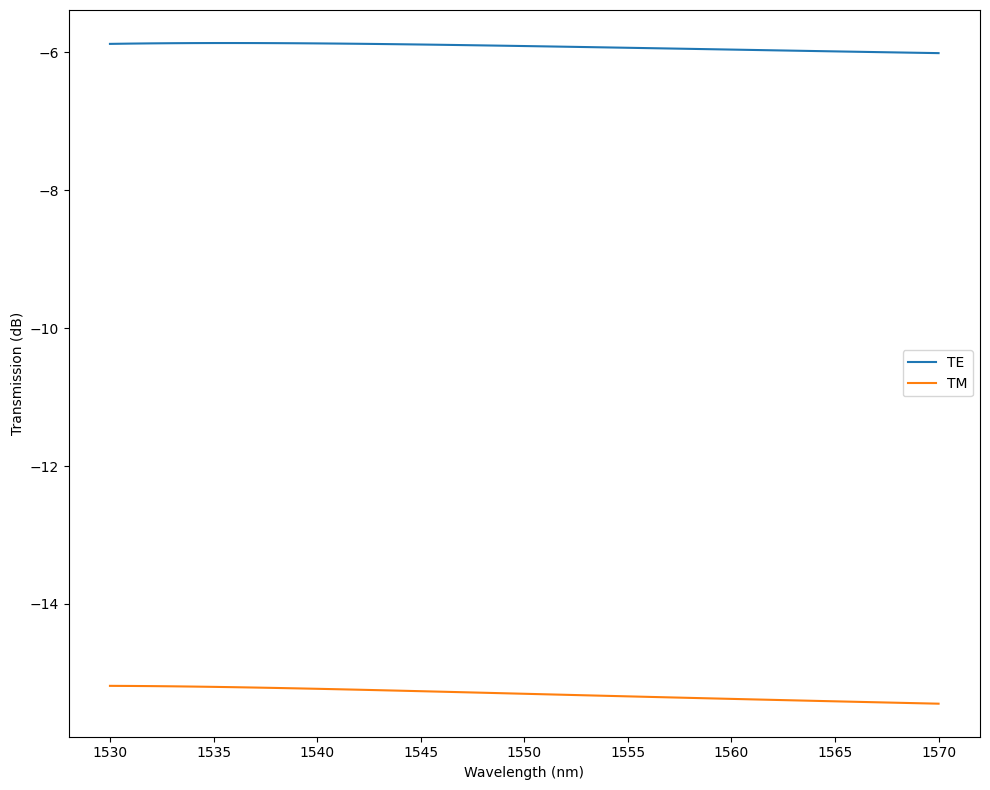

In [12]:
# Initial Simulation: Get TE TM transmission, also ER and field monitor

# make one figure/axes
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

s_matrix = rot_top.s_matrix(
    pf.C_0 / wavelengths, show_progress=False
)

# make sure ini ga kebalik TE-TM nya. cek pake mode solver
s0 = s_matrix[("P0@0", "P1@0")]
s1 = s_matrix[("P0@0", "P1@1")]
axs.plot(
    wavelengths * 1e3,
    10 * np.log10(np.abs(s0)),
    label=f"TE",
    linewidth=1.5,
)
axs.plot(
    wavelengths * 1e3,
    10 * np.log10(np.abs(s1)),
    label=f"TM",
    linewidth=1.5
)
axs.legend()
axs.set_xlabel("Wavelength (nm)")
axs.set_ylabel("Transmission (dB)")

plt.tight_layout()
plt.show()

In [13]:
# VALIDATE TE TM WITH FIELD MONITOR (TE mode when Ez=0 Hz!=0, TM mode when Ez!=0 Hz=0 IF PROPAGATION IS Z DIRECTION). Kemungkinan signal propagation kita di x axis.
# Check here https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/

## Inverse Design

Relevant source from tidy3d [basics](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/) and [example using field monitor](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/). Check TE TM with field mode instead. TE mode has Ez = 0 but Hz != 0. TM mode has Ez != 0 but Hz = 0 IF PROPAGATION IS Z DIRECTION. If x direction then change z to x. We can use this to check if the rotator is working properly. [Proof](https://physics.stackexchange.com/questions/78419/transverse-magnetic-tm-and-transverse-electric-te-modes). Autograd-like framework and implementation for digital metamaterial like ours reference [here](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/).

We can test several different algorithms to find the most optimal design for the hybrid rotator. The goal is to maximize the extinction ratio (ER) while also maintaining manufacturability constraints. Some of the algorithms we can test include: Autograd, [modified DBS](https://opg.optica.org/oe/fulltext.cfm?uri=oe-25-17-19721), Optuna, and [Bayesian Optimization](https://arxiv.org/abs/1807.02811), and many others. Keep in mind Tidy3d inverse design is expensive. Further exploration we can tune parameters such as the number of pixels, the resolution of the waveguide, and the length and width of the rotator. We can also explore different materials for the rotator, such as silicon nitride or silicon dioxide.

### Cost Estimation
According to Majumder, if we actually follow the same amount of iterations (50 iters), we will need 2 $\times$ 50 $\times$ 0.592 = **59.2 flexcredits**. Autograd uses 2 FDTD simulation per iteration. Max per batch simulation of this device is 3.012 credits. Actual S-matrix simulation costs 0.592 credits. We might be able to reduce the number of iterations with autograd tidy3d instead of using DBS from Majumder.

In [14]:
# Filter + project: turn a raw [0,1] parameter array into a smooth, binarizable density,
# same tidy3d.plugins.autograd approach as mode_conv_inv_des_pixelate.ipynb. Stay truly free-form
# on a fine grid first -- confining to the digital-metamaterial pixel lattice is a later, separate
# step (that notebook's own "Pixelation" section), not baked in here.
from tidy3d.plugins.autograd import make_filter_and_project

dl_design_region = 0.02  # um, fine grid spacing (5x finer than the 100 nm pixel lattice)
filter_radius = 0.15  # um
beta = 8  # binarization strength (placeholder until the optimization loop ramps it)

nx = int(rot_length / dl_design_region)  # fine cells along x (length)
ny = int(rot_width / dl_design_region)   # fine cells along y (width)

filter_project = make_filter_and_project(filter_radius, dl_design_region)

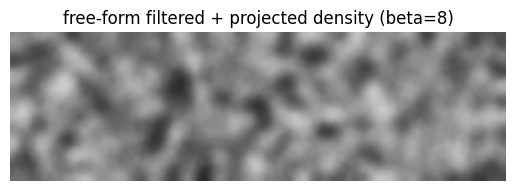

In [15]:
# free-form density on the fine grid -- no pixel lattice involved yet
params0 = np.random.default_rng(1).random((nx, ny))
density = filter_project(params0, beta)

plt.imshow(np.flipud(1 - density.T), cmap="gray", vmin=0, vmax=1)
plt.title(f"free-form filtered + projected density (beta={beta})")
plt.axis("off")
plt.show()

In [16]:
# PhotonForge's Rectangle/viewer geometry is polygon-based (GDS layers) -- there's no way to hand it
# a continuous [0,1] density directly. pf.Tidy3DModel's `structures=[...]` is the escape hatch: raw
# tidy3d Structures included straight into the simulation, same role as
# td.Structure.from_permittivity_array(...) in mode_conv_inv_des_pixelate.ipynb.
from tidy3d.plugins.autograd import rescale

freq0 = pf.C_0 / 1.55
si_layer_id = siepic_tech.layers["Si"].layer
eps_si = next(
    spec.medium["optical"].eps_model(freq0).real
    for spec in siepic_tech.extrusion_specs
    if spec.mask_spec.layer == si_layer_id
)


def make_density_structure(density, rot_length, rot_width, wg_height=0.22, center_xy=(0, 0)):
    """Raw tidy3d Structure carrying the free-form density directly (air -> silicon), covering the
    same design region create_hybrid_rotator_90 fills with pixels. `center_xy` places it -- needed
    when this is rebuilt at a reference's actual position after connect() (add_reference() only
    carries GDS/polygon geometry into a parent simulation, not a sub-component's own
    Tidy3DModel.structures, so the box has to be reconstructed there rather than reused)."""
    box = td.Box(center=(center_xy[0], center_xy[1], wg_height / 2), size=(rot_length, rot_width, wg_height))
    eps_data = rescale(density, 1, eps_si).reshape(density.shape + (1,))
    return td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

In [17]:
@pf.parametric_component
def create_hybrid_rotator_90_freeform(*, density, rot_length=5.0, rot_width=1.5):
    wg_height = 0.22

    hybrid_rotator_90_freeform = pf.Component("HybridRotator90Freeform")

    hybrid_rotator_90_freeform.add_port(
        pf.Port(center=(-rot_length / 2, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )
    hybrid_rotator_90_freeform.add_port(
        pf.Port(center=(rot_length / 2, 0), input_direction=180, spec=siepic_tech.ports["TE-TM_1550_500"])
    )

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )
    hybrid_rotator_90_freeform.add_model(
        pf.Tidy3DModel(
            structures=[make_density_structure(density, rot_length, rot_width, wg_height)],
            monitors=[field_monitor],
        ),
        "Tidy3DModel",
    )
    return hybrid_rotator_90_freeform

hybrid_rotator_90_freeform = create_hybrid_rotator_90_freeform(
    density=density, rot_length=rot_length, rot_width=rot_width
)

<Axes: title={'center': 'cross section at z=0.11 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

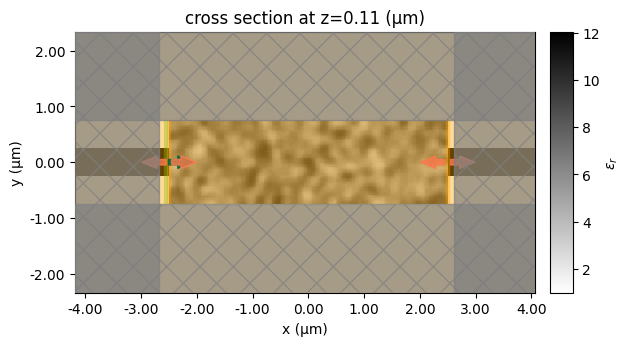

In [18]:
pf.tidy3d_plot(hybrid_rotator_90_freeform, plot_type="eps", z=0.11)

In [19]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(hybrid_rotator_90_freeform, plot_type="3d")

In [20]:
@pf.parametric_component
def create_hybrid_rotator_90_with_wg_freeform(*, density, wg_length=2.0, use_gc=False):
    wg_height = 0.22

    hybrid_rotator_90_with_wg_freeform = pf.Component("hybrid_rotator_90_with_wg_freeform")

    half_straight1 = pf.parametric.straight(port_spec="TE_1550_500", length=wg_length)
    half_straight2 = pf.parametric.straight(port_spec="TE-TM_1550_500", length=wg_length)
    grating_coupler = siepic.component("ebeam_gc_te1550")
    hybrid_rotator_90_freeform = create_hybrid_rotator_90_freeform(
        density=density, rot_length=rot_length, rot_width=rot_width
    )

    rot1_ref = hybrid_rotator_90_with_wg_freeform.add_reference(hybrid_rotator_90_freeform)
    hst1_ref = hybrid_rotator_90_with_wg_freeform.add_reference(half_straight1)
    hst2_ref = hybrid_rotator_90_with_wg_freeform.add_reference(half_straight2)

    rot1_ref.connect("P0", hst1_ref["P1"])
    hst2_ref.connect("P0", rot1_ref["P1"])

    if use_gc:
        gc1_ref = hybrid_rotator_90_with_wg_freeform.add_reference(grating_coupler)
        hst1_ref.connect("P0", gc1_ref["P0"])

    # rot1_ref only carries its GDS/polygon layout into this parent -- its own Tidy3DModel.structures
    # (the density box, since it isn't drawn on any GDS layer) does not propagate through
    # add_reference(). Rebuild it here at the reference's actual post-connect placement instead.
    design_structure = make_density_structure(
        density, rot_length, rot_width, wg_height, center_xy=rot1_ref.origin
    )

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )
    hybrid_rotator_90_with_wg_freeform.add_port(
        pf.Port(center=(0, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )
    hybrid_rotator_90_with_wg_freeform.add_port(
        pf.Port(
            center=(rot_length + 2 * wg_length, 0),
            input_direction=180,
            spec=siepic_tech.ports["TE-TM_1550_500"],
        )
    )
    hybrid_rotator_90_with_wg_freeform.add_model(
        pf.Tidy3DModel(structures=[design_structure], monitors=[field_monitor]), "Tidy3DModel"
    )
    return hybrid_rotator_90_with_wg_freeform

rot_top_freeform = create_hybrid_rotator_90_with_wg_freeform(density=density, wg_length=2.0, use_gc=False)

<Axes: title={'center': 'cross section at z=0.11 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

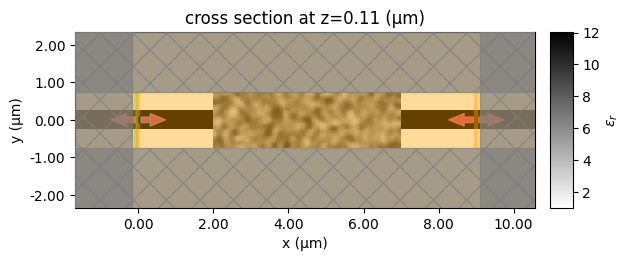

In [21]:
pf.tidy3d_plot(rot_top_freeform, plot_type="eps", z=0.11)

In [22]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(rot_top_freeform, plot_type="3d")

In [23]:
from tidy3d.plugins.mode import ModeSolver
from tidy3d.plugins.mode.web import run as run_mode_solver

# get_simulations() already builds the exact ModeSource PhotonForge uses per port (same pattern as
# cell 96e9cc9e) -- reuse its plane/mode_spec directly instead of reconstructing the port geometry.
simulations_freeform = rot_top_freeform.active_model.get_simulations(rot_top_freeform, freqs)
input_source = simulations_freeform["P0@0"].sources[0]
output_source = simulations_freeform["P1@0"].sources[0]

input_mode_solver = ModeSolver(
    simulation=simulations_freeform["P0@0"],
    plane=td.Box(center=input_source.center, size=input_source.size),
    mode_spec=input_source.mode_spec,
    freqs=[freq0],
)
output_mode_solver = ModeSolver(
    simulation=simulations_freeform["P1@0"],
    plane=td.Box(center=output_source.center, size=output_source.size),
    mode_spec=output_source.mode_spec,
    freqs=[freq0],
)

In [24]:
input_modes = run_mode_solver(input_mode_solver, reduce_simulation=True, verbose=False)
output_modes = run_mode_solver(output_mode_solver, reduce_simulation=True, verbose=False)

print("Input (P0) effective index:", np.array(input_modes.n_eff))
print("Output (P1) effective index:", np.array(output_modes.n_eff))

Input (P0) effective index: [[2.38012924]]
Output (P1) effective index: [[2.38012924 1.59734696]]


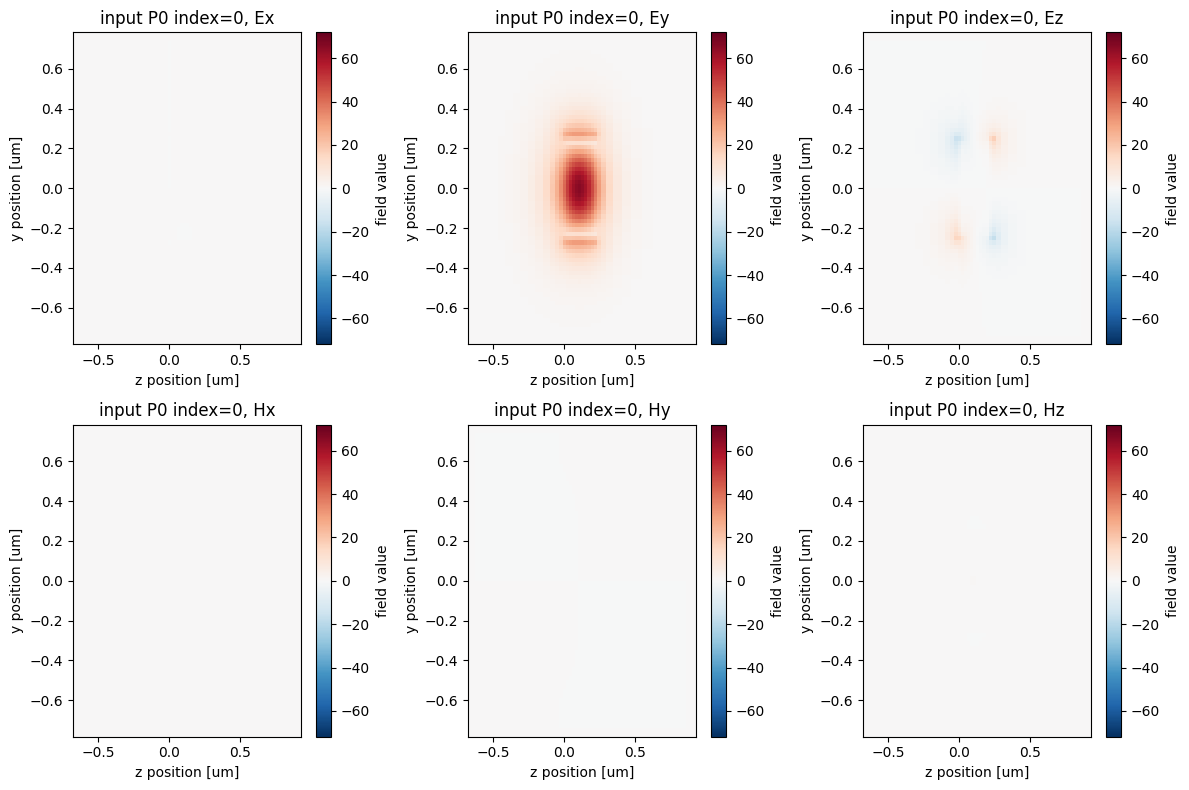

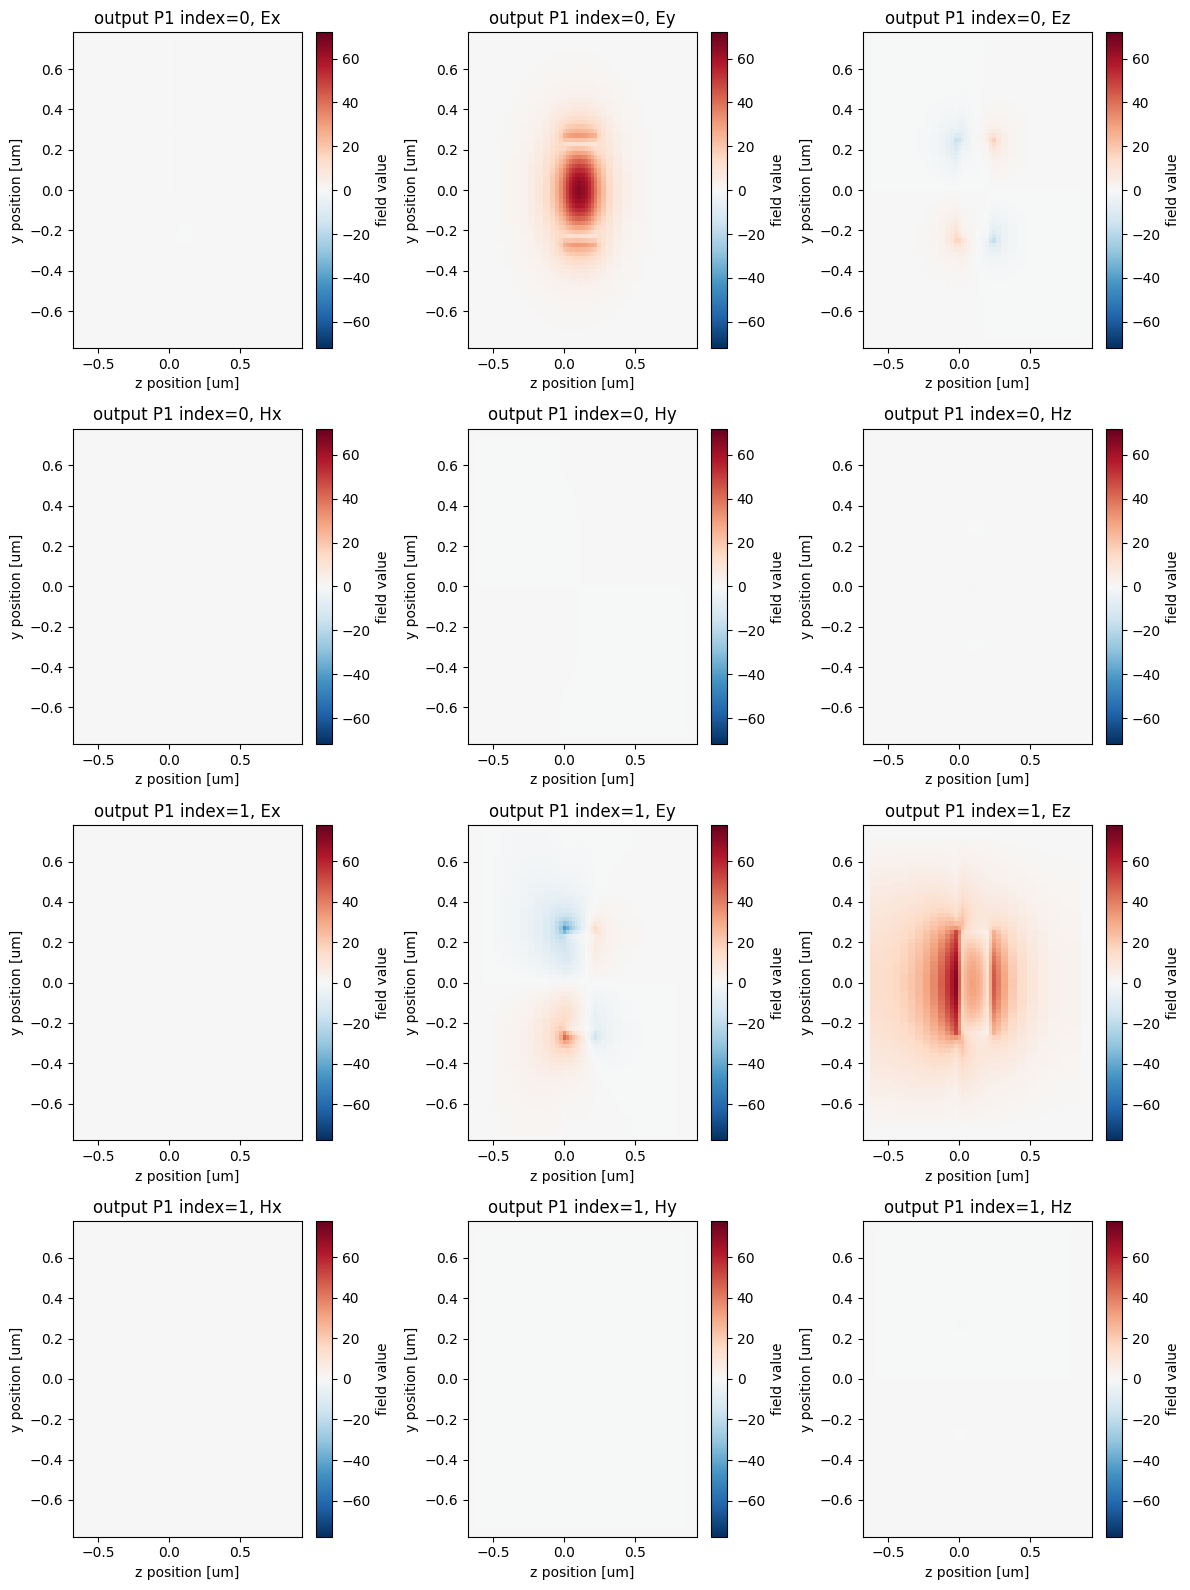

In [25]:
def plot_mode_fields(modes, num_modes, title):
    fields = ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz")
    fig, axs = plt.subplots(num_modes * 2, 3, figsize=(12, 4 * num_modes * 2), tight_layout=True)
    if num_modes == 1:
        axs = axs.reshape(2, 3)
    for mode_index in range(num_modes):
        vmax = 1.1 * max(abs(modes.field_components[f].sel(mode_index=mode_index)).max() for f in fields)
        for row_offset, row_fields in enumerate((fields[:3], fields[3:])):
            row = axs[2 * mode_index + row_offset]
            for field_name, ax in zip(row_fields, row):
                field = modes.field_components[field_name].sel(mode_index=mode_index)
                field.real.plot(ax=ax, vmin=-vmax, vmax=vmax, cmap="RdBu_r")
                ax.set_title(f"{title} index={mode_index}, {field_name}")
    plt.show()

plot_mode_fields(input_modes, input_source.mode_spec.num_modes, "input P0")
plot_mode_fields(output_modes, output_source.mode_spec.num_modes, "output P1")

In [26]:
def ez_fraction(modes, mode_index):
    """Ez dominance relative to in-plane Ey. TE mode ~ Ez negligible (fraction near 0);
    TM mode ~ Ez dominant (fraction near 1). Matches the Ez/Hz rule already noted above."""
    ez = np.abs(modes.field_components["Ez"].sel(mode_index=mode_index)).values
    ey = np.abs(modes.field_components["Ey"].sel(mode_index=mode_index)).values
    return ez.max() / (ey.max() + ez.max())

input_ez_frac = ez_fraction(input_modes, 0)
output_ez_fracs = [ez_fraction(output_modes, i) for i in range(output_source.mode_spec.num_modes)]

print(f"input P0@0: Ez fraction = {input_ez_frac:.3f} -> {'TM' if input_ez_frac > 0.5 else 'TE'}")
for i, f in enumerate(output_ez_fracs):
    print(f"output P1@{i}: Ez fraction = {f:.3f} -> {'TM' if f > 0.5 else 'TE'}")

input_is_te = input_ez_frac <= 0.5
output0_is_te = output_ez_fracs[0] <= 0.5
if input_is_te == output0_is_te:
    print("input matches output mode@0 -> P1@0 = TE, P1@1 = TM")
else:
    print("input matches output mode@1 -> P1@0 = TM, P1@1 = TE")

input P0@0: Ez fraction = 0.209 -> TE
output P1@0: Ez fraction = 0.209 -> TE
output P1@1: Ez fraction = 0.616 -> TM
input matches output mode@0 -> P1@0 = TE, P1@1 = TM


Effective index of computed modes (input P0): [[2.38012924]]


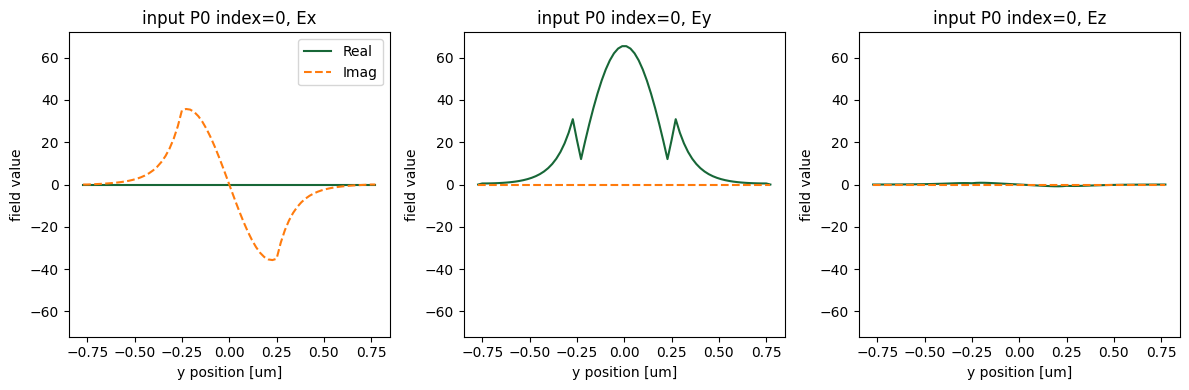

Effective index of computed modes (output P1): [[2.38012924 1.59734696]]


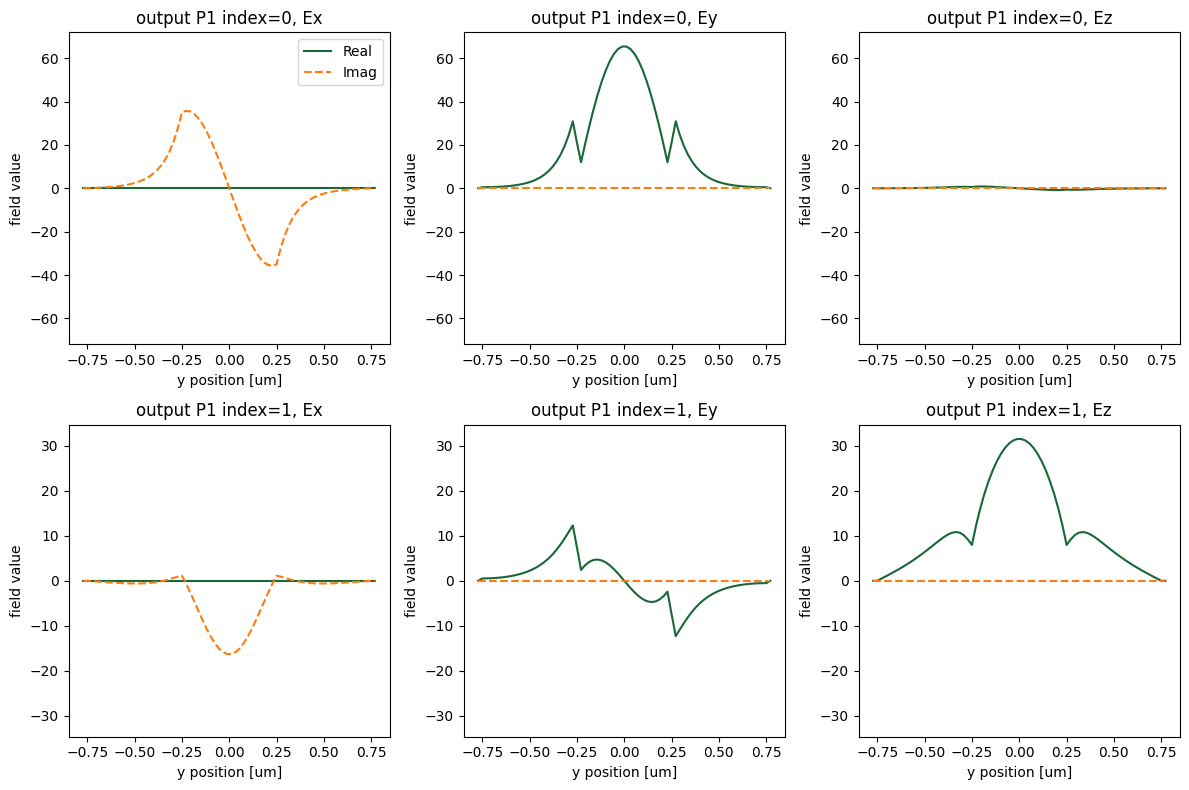

In [27]:
# Same plot as mode_conv_inv_des_pixelate.ipynb's mode-field cells (real/imag overlay vs a single
# axis, with a legend) -- their fields are already 1D (function of y only). Ours are 2D (y, z), so
# slice at a fixed z (waveguide vertical center) first to get the same 1D-over-y shape, then the
# rest of the reference code applies unchanged.
wg_height = 0.22


def plot_mode_fields_y(modes, num_modes, title, z=wg_height / 2):
    fig, axs = plt.subplots(num_modes, 3, figsize=(12, 4 * num_modes), tight_layout=True)
    if num_modes == 1:
        axs = axs[np.newaxis, :]
    for mode_index in range(num_modes):
        vmax = 1.1 * max(
            abs(modes.field_components[n].sel(mode_index=mode_index, z=z, method="nearest")).max()
            for n in ("Ex", "Ey", "Ez")
        )
        for field_name, ax in zip(("Ex", "Ey", "Ez"), axs[mode_index]):
            field = modes.field_components[field_name].sel(mode_index=mode_index, z=z, method="nearest")
            field.real.plot(label="Real", ax=ax)
            field.imag.plot(ls="--", label="Imag", ax=ax)
            ax.set_title(f"{title} index={mode_index}, {field_name}")
            ax.set_ylim(-vmax, vmax)
    axs[0, 0].legend()
    plt.show()


print("Effective index of computed modes (input P0):", np.array(input_modes.n_eff))
plot_mode_fields_y(input_modes, input_source.mode_spec.num_modes, "input P0")

print("Effective index of computed modes (output P1):", np.array(output_modes.n_eff))
plot_mode_fields_y(output_modes, output_source.mode_spec.num_modes, "output P1")

In [28]:
# Inverse Design: Get the highest possible ER while also maintaining manufacturability constraints.